/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 82ms/step - accuracy: 0.2804 - loss: 1.9349 - val_accuracy: 0.5287 - val_loss: 1.3534
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.4737 - loss: 1.4453 - val_accuracy: 0.5689 - val_loss: 1.2302
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 78ms/step - accuracy: 0.5416 - loss: 1.2980 - val_accuracy: 0.6213 - val_loss: 1.0882
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 82ms/step - accuracy: 0.5740 - loss: 1.2038 - val_accuracy: 0.6304 - val_loss: 1.0627
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 78ms/step - accuracy: 0.5929 - loss: 1.1464 - val_accuracy: 0.6453 - val_loss: 1.0139
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step - accuracy: 0.6071 - loss: 1.1160 - val_accuracy: 0.6593 - val_loss: 0.9790
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.6164 - loss: 1.0859 - val_accuracy: 0.6648 - val_loss: 0.9698
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 78ms/step - accuracy: 0.6325 - loss: 1.0527 - 

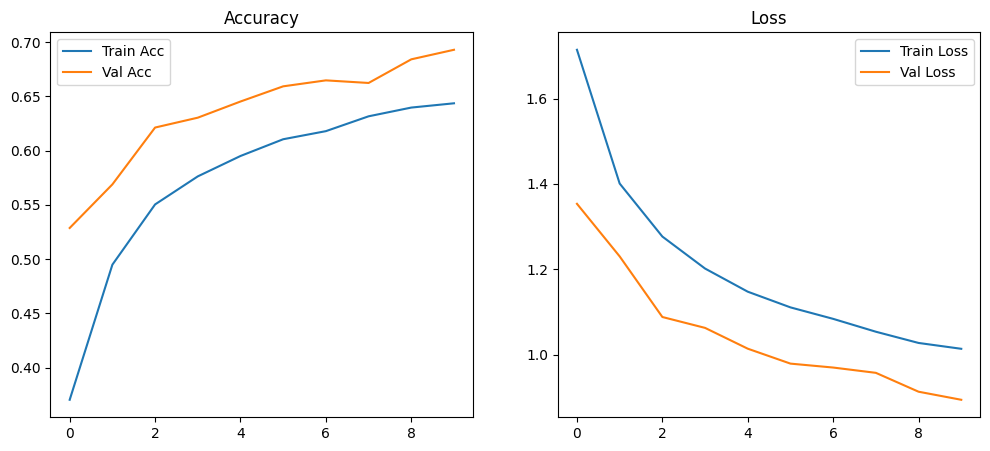

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


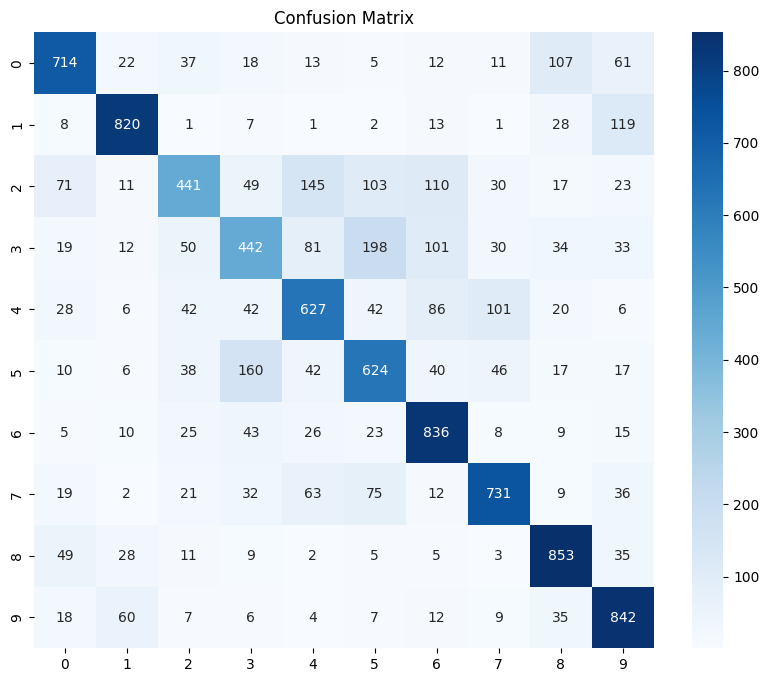


Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.71      0.74      1000
           1       0.84      0.82      0.83      1000
           2       0.66      0.44      0.53      1000
           3       0.55      0.44      0.49      1000
           4       0.62      0.63      0.63      1000
           5       0.58      0.62      0.60      1000
           6       0.68      0.84      0.75      1000
           7       0.75      0.73      0.74      1000
           8       0.76      0.85      0.80      1000
           9       0.71      0.84      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



In [ ]:
# Task 1 - Image Classification (CIFAR-10)

# --- 1. Imports ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# --- 2. Load & Preprocess Data ---
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten labels
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

# --- 3. Build Model ---
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# --- 4. Compile ---
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# --- 5. Train ---
history = model.fit(x_train, y_train, epochs=10, batch_size=64,
                    validation_data=(x_test, y_test))

# --- 6. Evaluate ---
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("\nTest Accuracy:", test_acc)

# --- 7. Plot Accuracy & Loss ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

# --- 8. Confusion Matrix ---
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# --- 9. Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))
